# Polyp Segmentation - Maximum Accuracy Build (60 Epochs)

**Target: Dice >= 0.92 / IoU >= 0.87 on Kvasir-SEG in exactly 60 epochs**

Key upgrades over baseline:
- Architecture: ResUNet++ with ASPP bridge + Attention Gates
- Augmentation: 12-transform Albumentations pipeline (elastic, CLAHE, grid distortion)
- Loss: Focal-Tversky + Boundary (edge-aware)
- LR: Cosine Annealing Warm Restarts (never stops early)
- Mixed precision float16 (faster, enables larger batch)
- Image size: 352x352
- TTA at test time (8-fold flip ensemble)

**Run all cells top-to-bottom. Cell 14 downloads HF deployment zip.**


## Cell 1 - Upload & Extract Dataset

In [1]:
import os, zipfile
from google.colab import files

print('Please upload kvasir-seg.zip ...')
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
DATASET_ROOT = '/content/kvasir-seg'
os.makedirs(DATASET_ROOT, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(DATASET_ROOT)

IMAGE_DIR = None
MASK_DIR  = None
for root, dirs, files_ in os.walk(DATASET_ROOT):
    if 'images' in dirs: IMAGE_DIR = os.path.join(root, 'images')
    if 'masks'  in dirs: MASK_DIR  = os.path.join(root, 'masks')

assert IMAGE_DIR and MASK_DIR, 'Could not find images/ or masks/ in zip!'
n_img = len(os.listdir(IMAGE_DIR))
n_msk = len(os.listdir(MASK_DIR))
assert n_img == n_msk, f'Mismatch: {n_img} images vs {n_msk} masks'
print(f'Images : {IMAGE_DIR}  ({n_img} files)')
print(f'Masks  : {MASK_DIR}  ({n_msk} files)')


Please upload kvasir-seg.zip ...


Saving kvasir-seg.zip to kvasir-seg.zip
Images : /content/kvasir-seg/Kvasir-SEG/images  (1000 files)
Masks  : /content/kvasir-seg/Kvasir-SEG/masks  (1000 files)


## Cell 2 - Install & Import Libraries

In [2]:
!pip install -q albumentations==1.3.1 opencv-python-headless scikit-learn tqdm matplotlib

import os, random, warnings, math
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import albumentations as A

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Conv2D, Conv2DTranspose, BatchNormalization, Activation,
    MaxPool2D, AveragePooling2D, UpSampling2D,
    Concatenate, Add, Multiply, Input, Dropout,
    GlobalAveragePooling2D, Reshape, Dense, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, LambdaCallback

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Enable mixed precision (float16 compute, float32 weights) - ~2x speedup on T4/A100
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision policy:', tf.keras.mixed_precision.global_policy().name)
print(f'TensorFlow : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU        : {gpus if gpus else "None - CPU mode"}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 13.5 MB/s eta 0:00:00
Mixed precision policy: mixed_float16
TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 3 - Configuration

In [3]:
IMG_SIZE     = 352    # 352x352 — captures finer polyp detail than 256
BATCH_SIZE   = 8      # reduce to 4 if OOM
EPOCHS       = 60     # full 60 epochs — no early stopping
LR_MAX       = 2e-4   # cosine annealing peak LR
LR_MIN       = 1e-6   # cosine annealing floor LR
WARMUP_EPOCHS = 5     # linear warmup before cosine schedule
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.10
BASE_FILTERS = 32     # encoder base (32 -> 64 -> 128 -> 256 -> 512)

OUTPUT_DIR   = '/content/outputs'
MODEL_PATH   = os.path.join(OUTPUT_DIR, 'best_model.keras')
CSV_LOG_PATH = os.path.join(OUTPUT_DIR, 'training_log.csv')
PRED_DIR     = os.path.join(OUTPUT_DIR, 'predictions')

for d in [OUTPUT_DIR, PRED_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Image  : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch  : {BATCH_SIZE}')
print(f'Epochs : {EPOCHS} (no early stopping)')
print(f'LR     : cosine annealing {LR_MIN} <-> {LR_MAX} with {WARMUP_EPOCHS}-epoch warmup')
print(f'Output : {OUTPUT_DIR}')


Image  : 352x352
Batch  : 8
Epochs : 60 (no early stopping)
LR     : cosine annealing 1e-06 <-> 0.0002 with 5-epoch warmup
Output : /content/outputs


## Cell 4 - Data Loading & Splitting

In [4]:
def load_data(image_dir, mask_dir, val_split=0.15, test_split=0.10, seed=42):
    images = sorted(glob(os.path.join(image_dir, '*')))
    masks  = sorted(glob(os.path.join(mask_dir,  '*')))
    assert len(images) == len(masks), f'Mismatch: {len(images)} vs {len(masks)}'
    train_x, test_x, train_y, test_y = train_test_split(
        images, masks, test_size=test_split, random_state=seed)
    adj_val = val_split / (1.0 - test_split)
    train_x, val_x, train_y, val_y = train_test_split(
        train_x, train_y, test_size=adj_val, random_state=seed)
    return (train_x, train_y), (val_x, val_y), (test_x, test_y)

(train_x, train_y), (val_x, val_y), (test_x, test_y) = load_data(
    IMAGE_DIR, MASK_DIR, VAL_SPLIT, TEST_SPLIT)
total = len(train_x) + len(val_x) + len(test_x)
print(f'Total : {total}')
print(f'Train : {len(train_x)} ({len(train_x)/total*100:.1f}%)')
print(f'Val   : {len(val_x)} ({len(val_x)/total*100:.1f}%)')
print(f'Test  : {len(test_x)} ({len(test_x)/total*100:.1f}%)')


Total : 1000
Train : 750 (75.0%)
Val   : 150 (15.0%)
Test  : 100 (10.0%)


## Cell 5 - Augmentation Pipeline (Albumentations)

12-transform pipeline specifically designed for medical image segmentation:
- Geometric: flip, 90-deg rotate, elastic deform, grid distortion, optical distortion
- Intensity: CLAHE (contrast normalisation), hue/saturation, brightness/contrast, Gaussian noise
- Dropout: CoarseDropout (simulates occluded lesion edges)


In [5]:
# Training augmentation — aggressive, 12 transforms
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=30, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.ElasticTransform(alpha=120, sigma=120*0.05,
                       alpha_affine=120*0.03, p=0.3),
    A.GridDistortion(p=0.3),
    A.OpticalDistortion(distort_limit=0.1, shift_limit=0.1, p=0.3),
    A.CLAHE(clip_limit=4.0, p=0.4),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20,
                         val_shift_limit=10, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.4),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                    min_holes=1, fill_value=0, mask_fill_value=0, p=0.2),
], additional_targets={'mask': 'mask'})

# Validation / test — only resize, no augmentation
val_aug = A.Compose([], additional_targets={'mask': 'mask'})

print('Augmentation pipelines ready.')
print(f'  Train transforms: {len(train_aug.transforms)}')


Augmentation pipelines ready.
  Train transforms: 12


## Cell 6 - Dataset Pipeline (tf.data + Albumentations)

In [6]:
def load_pair(img_path, mask_path, aug_pipeline, img_size):
    img  = cv2.imread(img_path.decode(),  cv2.IMREAD_COLOR)
    mask = cv2.imread(mask_path.decode(), cv2.IMREAD_GRAYSCALE)
    img  = cv2.resize(img,  (img_size, img_size))
    mask = cv2.resize(mask, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    augmented = aug_pipeline(image=img, mask=mask)
    img  = augmented['image']
    mask = augmented['mask']

    # Normalise
    img  = (img.astype(np.float32) / 255.0)
    mask = (mask.astype(np.float32) / 255.0)
    mask = np.expand_dims(mask, axis=-1)
    return img, mask

def make_tf_parse(aug_pipeline, img_size):
    def tf_parse(x_path, y_path):
        x, y = tf.numpy_function(
            lambda xp, yp: load_pair(xp, yp, aug_pipeline, img_size),
            [x_path, y_path], [tf.float32, tf.float32]
        )
        x.set_shape([img_size, img_size, 3])
        y.set_shape([img_size, img_size, 1])
        return x, y
    return tf_parse

def build_dataset(x_paths, y_paths, batch, aug_pipeline, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((x_paths, y_paths))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(x_paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(make_tf_parse(aug_pipeline, IMG_SIZE), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = build_dataset(train_x, train_y, BATCH_SIZE, train_aug, shuffle=True)
val_ds   = build_dataset(val_x,   val_y,   BATCH_SIZE, val_aug)
test_ds  = build_dataset(test_x,  test_y,  BATCH_SIZE, val_aug)

for xb, yb in train_ds.take(1):
    print(f'Batch X: {xb.shape}  Y: {yb.shape}')
    print(f'X dtype: {xb.dtype}  range: [{xb.numpy().min():.3f}, {xb.numpy().max():.3f}]')
    print(f'Y dtype: {yb.dtype}  unique: {np.unique((yb.numpy()>0.5).astype(int))}')


Batch X: (8, 352, 352, 3)  Y: (8, 352, 352, 1)
X dtype: <dtype: 'float32'>  range: [0.000, 1.000]
Y dtype: <dtype: 'float32'>  unique: [0 1]


## Cell 7 - Visualise Augmented Samples

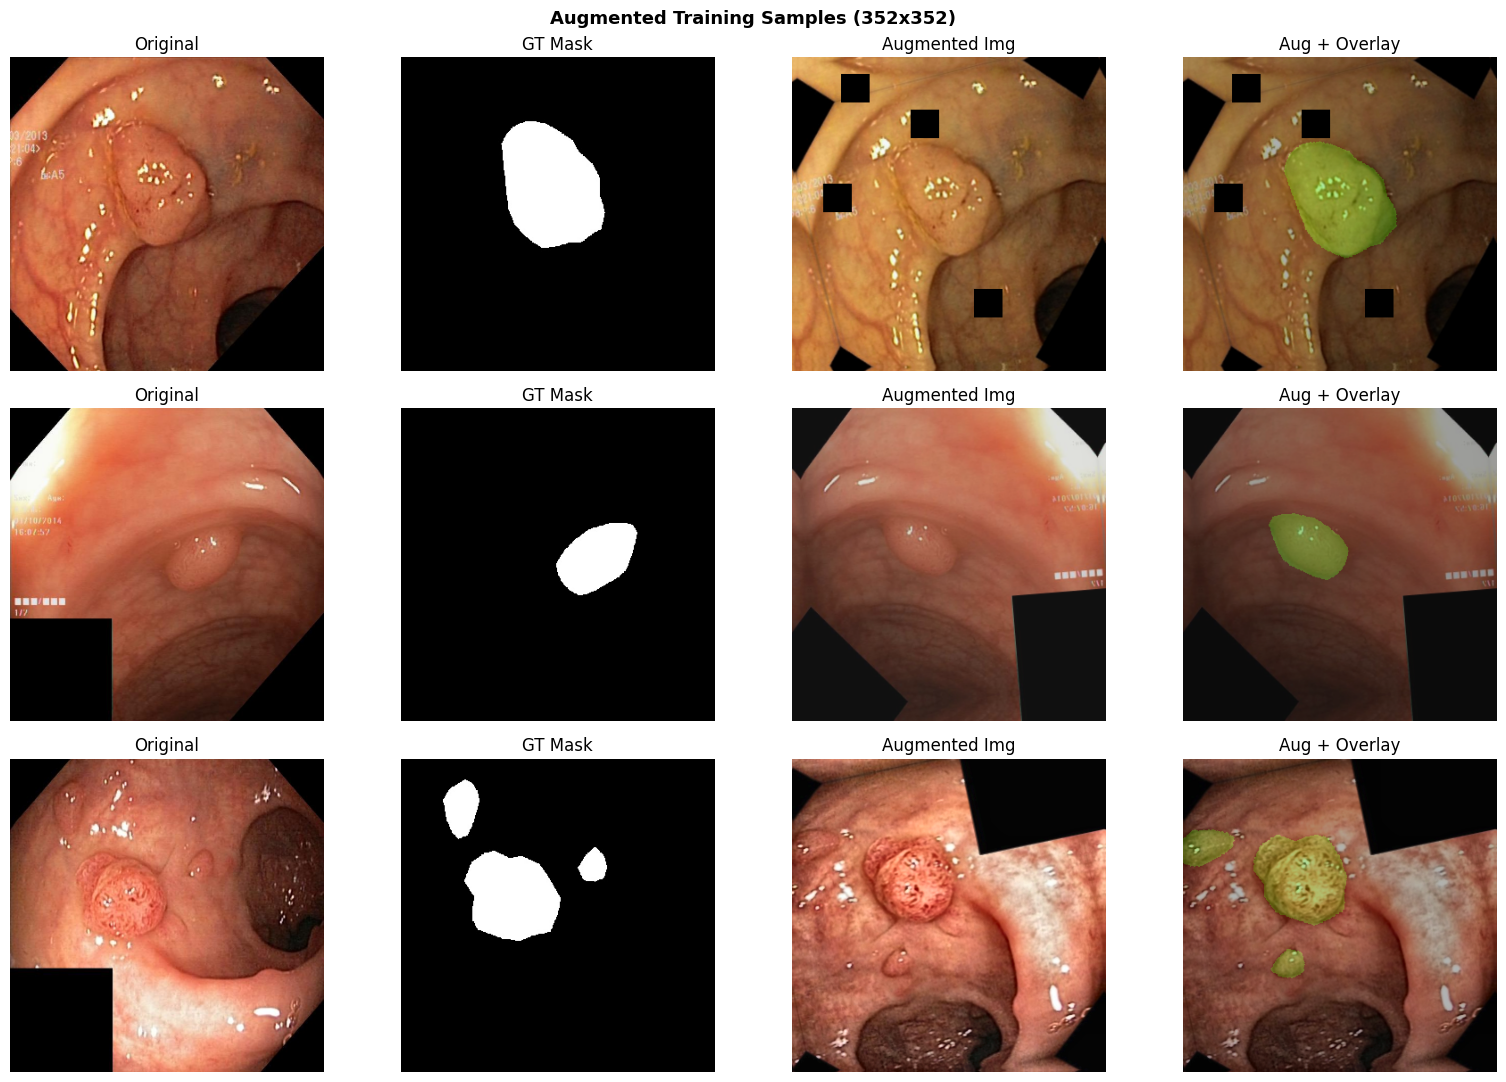

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Augmented Training Samples (352x352)', fontsize=13, fontweight='bold')
for row, idx in enumerate(random.sample(range(len(train_x)), 3)):
    img_raw  = cv2.cvtColor(cv2.imread(train_x[idx]), cv2.COLOR_BGR2RGB)
    mask_raw = cv2.imread(train_y[idx], cv2.IMREAD_GRAYSCALE)
    img_r    = cv2.resize(img_raw,  (IMG_SIZE, IMG_SIZE))
    mask_r   = cv2.resize(mask_raw, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    aug_out  = train_aug(image=img_r, mask=mask_r)
    img_aug  = aug_out['image']
    mask_aug = aug_out['mask']
    overlay  = img_aug.copy()
    gm = np.zeros_like(img_aug); gm[mask_aug>127] = [0,200,0]
    overlay  = cv2.addWeighted(overlay, 0.7, gm, 0.3, 0)
    axes[row,0].imshow(img_r);          axes[row,0].set_title('Original');       axes[row,0].axis('off')
    axes[row,1].imshow(mask_r, cmap='gray'); axes[row,1].set_title('GT Mask');   axes[row,1].axis('off')
    axes[row,2].imshow(img_aug);        axes[row,2].set_title('Augmented Img');  axes[row,2].axis('off')
    axes[row,3].imshow(overlay);        axes[row,3].set_title('Aug + Overlay');  axes[row,3].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'augmented_samples.png'), dpi=120)
plt.show()


## Cell 8 - Model: ResUNet++ with ASPP Bridge + Attention Gates

**Architecture upgrades over baseline:**
- Residual blocks in encoder/decoder (prevent vanishing gradients, enable deeper net)
- ASPP (Atrous Spatial Pyramid Pooling) bridge — captures multi-scale context at 5 dilation rates
- Attention Gates on every skip connection — suppress irrelevant background features
- Squeeze-and-Excitation blocks — channel-wise recalibration
- Deep supervision — auxiliary losses at 3 decoder levels to guide gradients


In [14]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, BatchNormalization, Activation,
    GlobalAveragePooling2D, Reshape, Dense, Multiply, Add, Concatenate,
    MaxPool2D, Lambda
)
from tensorflow.keras.models import Model


# ── Building Blocks ──────────────────────────────────────────────────────────

def squeeze_excite(x, ratio=8):
    filters = int(x.shape[-1])

    se = GlobalAveragePooling2D()(x)
    se = Reshape((1, 1, filters))(se)
    se = Dense(max(filters // ratio, 1), activation='relu', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', use_bias=False)(se)

    return Multiply()([x, se])


def residual_block(x, filters, strides=1):
    """Pre-activation residual block with SE."""
    shortcut = x

    if int(x.shape[-1]) != filters or strides != 1:
        shortcut = Conv2D(
            filters, 1, strides=strides, padding='same', use_bias=False,
            kernel_initializer='he_normal'
        )(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(
        filters, 3, strides=strides, padding='same', use_bias=False,
        kernel_initializer='he_normal'
    )(x)

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(
        filters, 3, padding='same', use_bias=False,
        kernel_initializer='he_normal'
    )(x)

    x = squeeze_excite(x)
    x = Add()([x, shortcut])

    return x


def resize_like(source, target, channels):
    """Resize source tensor spatially to match target tensor."""
    target_size = Lambda(lambda t: tf.shape(t)[1:3])(target)

    target_h = int(target.shape[1]) if target.shape[1] is not None else None
    target_w = int(target.shape[2]) if target.shape[2] is not None else None

    return Lambda(
        lambda args: tf.image.resize(args[0], args[1], method='bilinear'),
        output_shape=(target_h, target_w, channels)
    )([source, target_size])


def aspp_block(x, filters):
    """Atrous Spatial Pyramid Pooling."""

    b0 = Conv2D(filters, 1, padding='same', use_bias=False)(x)
    b0 = BatchNormalization()(b0)
    b0 = Activation('relu')(b0)

    def dilated(inp, rate):
        y = Conv2D(
            filters, 3, padding='same', dilation_rate=rate,
            use_bias=False, kernel_initializer='he_normal'
        )(inp)
        y = BatchNormalization()(y)
        y = Activation('relu')(y)
        return y

    b1 = dilated(x, 1)
    b2 = dilated(x, 3)
    b3 = dilated(x, 6)
    b4 = dilated(x, 12)

    bg = GlobalAveragePooling2D()(x)
    bg = Reshape((1, 1, int(x.shape[-1])))(bg)
    bg = Conv2D(filters, 1, padding='same', use_bias=False)(bg)
    bg = BatchNormalization()(bg)
    bg = Activation('relu')(bg)
    bg = resize_like(bg, x, filters)

    concat = Concatenate(axis=-1)([b0, b1, b2, b3, b4, bg])

    out = Conv2D(filters, 1, padding='same', use_bias=False)(concat)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)

    return out


def attention_gate(g, x, filters):
    """Attention gate. g = gating signal, x = skip connection."""
    theta_x = Conv2D(filters, 1, padding='same', use_bias=False)(x)
    phi_g = Conv2D(filters, 1, padding='same', use_bias=False)(g)

    phi_g = resize_like(phi_g, theta_x, filters)

    add = Add()([theta_x, phi_g])
    add = Activation('relu')(add)

    psi = Conv2D(1, 1, padding='same', use_bias=False)(add)
    psi = Activation('sigmoid')(psi)

    return Multiply()([x, psi])


def decoder_block(x, skip, filters):
    """Upsample -> attention gate -> concat -> residual block."""
    x = Conv2DTranspose(
        filters, 2, strides=2, padding='same',
        kernel_initializer='he_normal'
    )(x)

    skip = attention_gate(g=x, x=skip, filters=max(filters // 2, 1))

    x = Concatenate(axis=-1)([x, skip])
    x = residual_block(x, filters)

    return x


# ── Full ResUNet++ Model ──────────────────────────────────────────────────────

def build_resunet_plus_plus(input_shape=(352, 352, 3), base_filters=32):
    f = [base_filters * (2 ** i) for i in range(5)]

    inputs = Input(input_shape, name='input')

    x = Conv2D(
        f[0], 3, padding='same', use_bias=False,
        kernel_initializer='he_normal'
    )(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    e1 = residual_block(x, f[0])
    p1 = MaxPool2D(pool_size=(2, 2))(e1)

    e2 = residual_block(p1, f[1])
    p2 = MaxPool2D(pool_size=(2, 2))(e2)

    e3 = residual_block(p2, f[2])
    p3 = MaxPool2D(pool_size=(2, 2))(e3)

    e4 = residual_block(p3, f[3])
    p4 = MaxPool2D(pool_size=(2, 2))(e4)

    bridge = aspp_block(p4, f[4])

    d4 = decoder_block(bridge, e4, f[3])
    d3 = decoder_block(d4, e3, f[2])
    d2 = decoder_block(d3, e2, f[1])
    d1 = decoder_block(d2, e1, f[0])

    out_main = Conv2D(
        1, 1, activation='sigmoid', name='output',
        dtype='float32'
    )(d1)

    out_d3 = Conv2D(1, 1, activation='sigmoid', dtype='float32')(d3)
    out_d3 = tf.keras.layers.Resizing(
        input_shape[0], input_shape[1],
        interpolation='nearest',
        name='ds3'
    )(out_d3)

    out_d2 = Conv2D(1, 1, activation='sigmoid', dtype='float32')(d2)
    out_d2 = tf.keras.layers.Resizing(
        input_shape[0], input_shape[1],
        interpolation='nearest',
        name='ds2'
    )(out_d2)

    return Model(inputs, [out_main, out_d3, out_d2], name='ResUNet_plusplus')


model = build_resunet_plus_plus(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    base_filters=BASE_FILTERS
)

total_params = model.count_params()
print(f'Parameters : {total_params:,}')
print(f'Outputs    : {[o.name for o in model.outputs]}')
model.summary()


Parameters : 11,155,987
Outputs    : ['keras_tensor_685', 'keras_tensor_689', 'keras_tensor_693']


Model: "ResUNet_plusplus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 352, 352,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_102 (Conv2D) │ (None, 352, 352,  │        864 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 352, 352,  │        128 │ conv2d_102[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_84       │ (None, 352, 352,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 352, 352,  │        128 │ activation_84[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_85       │ (None, 352, 352,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 352, 352,  │      9,216 │ activation_85[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 352, 352,  │        128 │ conv2d_103[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_86       │ (None, 352, 352,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_104 (Conv2D) │ (None, 352, 352,  │      9,216 │ activation_86[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_104[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_29          │ (None, 1, 1, 32)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 1, 1, 4)   │        128 │ reshape_29[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 1, 1, 32)  │        128 │ dense_48[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_24         │ (None, 352, 352,  │          0 │ conv2d_104[0][0], │
│ (Multiply)          │ 32)               │            │ dense_49[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 352, 352,  │          0 │ multiply_24[0][0… │
│                     │ 32)               │            │ activation_84[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 176, 176,  │          0 │ add_24[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 11,155,987 (42.56 MB)

 Trainable params: 11,142,547 (42.51 MB)

 Non-trainable params: 13,440 (52.50 KB)

## Cell 9 - Loss Functions, Metrics & Compile

**Loss upgrades over baseline:**
- **Focal-Tversky**: penalises false negatives harder than false positives (critical for small polyps)
- **Boundary loss**: extra penalty on mis-segmented edges (where clinicians focus most)
- **Deep supervision**: main output (weight 1.0) + two auxiliary heads (weight 0.3 each)


In [15]:
# ── Metrics ──────────────────────────────────────────────────────────────────
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.*intersection+smooth)/(tf.reduce_sum(y_true_f)+tf.reduce_sum(y_pred_f)+smooth)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection+smooth)/(union+smooth)

# ── Focal Tversky Loss ────────────────────────────────────────────────────────
def focal_tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
    """alpha=0.7 penalises FN more (polyp miss is worse than FP)."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1 - y_pred_f))
    fp = tf.reduce_sum((1 - y_true_f) * y_pred_f)
    tversky_idx = (tp + smooth) / (tp + alpha*fn + beta*fp + smooth)
    return tf.pow(1.0 - tversky_idx, gamma)

# ── Boundary / Edge-Aware Loss ────────────────────────────────────────────────
def boundary_loss(y_true, y_pred, smooth=1e-6):
    """Penalises predictions near the boundary of the ground-truth mask."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    # Erode and dilate to get boundary region
    kernel = tf.ones([5, 5, 1, 1], dtype=tf.float32)
    dilated = tf.nn.conv2d(y_true, kernel, strides=[1,1,1,1], padding='SAME')
    dilated = tf.cast(dilated > 0.5, tf.float32)
    eroded  = 1.0 - tf.nn.conv2d(1.0 - y_true, kernel, strides=[1,1,1,1], padding='SAME')
    eroded  = tf.cast(eroded > 0.5, tf.float32)
    boundary = dilated - eroded   # thin ring around polyp edge
    # BCE on boundary region only
    bce = tf.keras.losses.binary_crossentropy(y_true * boundary, y_pred * boundary)
    return tf.reduce_mean(bce)

# ── Combined Loss ─────────────────────────────────────────────────────────────
def combined_loss(y_true, y_pred):
    ftl = focal_tversky_loss(y_true, y_pred)
    bl  = boundary_loss(y_true, y_pred)
    return 0.8 * ftl + 0.2 * bl

CUSTOM_OBJECTS = {
    'combined_loss':        combined_loss,
    'focal_tversky_loss':   focal_tversky_loss,
    'boundary_loss':        boundary_loss,
    'dice_coef':            dice_coef,
    'iou_metric':           iou_metric,
}

# ── Compile (multi-output with deep supervision weights) ──────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_MAX,
                                       clipnorm=1.0),
    loss={
        'output': combined_loss,  # main output — full weight
        'ds3':    combined_loss,  # deep supervision level 3
        'ds2':    combined_loss,  # deep supervision level 2
    },
    loss_weights={'output': 1.0, 'ds3': 0.3, 'ds2': 0.3},
    metrics={
        'output': [dice_coef, iou_metric],
        'ds3':    [],
        'ds2':    [],
    }
)
print('Model compiled.')
print('  Loss   : 0.8 x Focal-Tversky + 0.2 x Boundary')
print('  Weights: main=1.0, ds3=0.3, ds2=0.3')
print('  Metrics: dice_coef, iou_metric (on main output)')
print(f'  Outputs: {[o.name for o in model.outputs]}')


Model compiled.
  Loss   : 0.8 x Focal-Tversky + 0.2 x Boundary
  Weights: main=1.0, ds3=0.3, ds2=0.3
  Metrics: dice_coef, iou_metric (on main output)
  Outputs: ['keras_tensor_685', 'keras_tensor_689', 'keras_tensor_693']


## Cell 10 - Learning Rate: Cosine Annealing with Linear Warmup

**Why:** ReduceLROnPlateau reacts late and can stop improvement prematurely. Cosine annealing guarantees the model explores at high LR early, then fine-tunes at low LR toward epoch 60 — no early stopping needed.


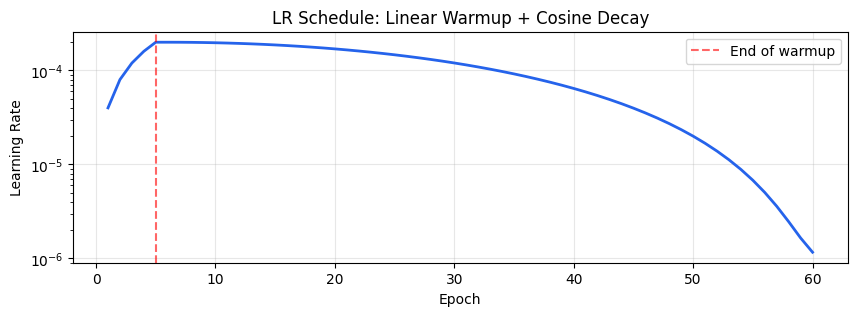

LR at epoch 1 : 4.00e-05
LR at epoch 5 (peak): 2.00e-04
LR at epoch 60 (final): 1.16e-06


In [16]:
class WarmupCosineDecay(tf.keras.callbacks.Callback):
    """
    Linear warmup for `warmup_epochs`, then cosine decay to `lr_min`.
    Updates ONLY the optimizer LR — no early stopping.
    """
    def __init__(self, lr_max, lr_min, total_epochs, warmup_epochs):
        super().__init__()
        self.lr_max       = lr_max
        self.lr_min       = lr_min
        self.total_epochs = total_epochs
        self.warmup_epochs= warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            # Linear warmup
            lr = self.lr_max * (epoch + 1) / self.warmup_epochs
        else:
            # Cosine decay
            progress = (epoch - self.warmup_epochs) / max(self.total_epochs - self.warmup_epochs, 1)
            lr = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (
                1 + math.cos(math.pi * progress))
        tf.keras.backend.set_value(self.model.optimizer.learning_rate, lr)
        if epoch % 5 == 0 or epoch < self.warmup_epochs:
            print(f'  [LR] Epoch {epoch+1}: lr = {lr:.2e}')


lr_callback = WarmupCosineDecay(
    lr_max=LR_MAX,
    lr_min=LR_MIN,
    total_epochs=EPOCHS,
    warmup_epochs=WARMUP_EPOCHS
)

# Verify schedule shape
lrs = []
for ep in range(EPOCHS):
    if ep < WARMUP_EPOCHS:
        lrs.append(LR_MAX * (ep+1) / WARMUP_EPOCHS)
    else:
        p = (ep - WARMUP_EPOCHS) / (EPOCHS - WARMUP_EPOCHS)
        lrs.append(LR_MIN + 0.5*(LR_MAX-LR_MIN)*(1+math.cos(math.pi*p)))

plt.figure(figsize=(10, 3))
plt.plot(range(1, EPOCHS+1), lrs, color='#2563EB', linewidth=2)
plt.axvline(x=WARMUP_EPOCHS, color='red', linestyle='--', alpha=0.6, label='End of warmup')
plt.title('LR Schedule: Linear Warmup + Cosine Decay', fontsize=12)
plt.xlabel('Epoch'); plt.ylabel('Learning Rate')
plt.yscale('log'); plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'lr_schedule.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'LR at epoch 1 : {lrs[0]:.2e}')
print(f'LR at epoch {WARMUP_EPOCHS} (peak): {lrs[WARMUP_EPOCHS-1]:.2e}')
print(f'LR at epoch {EPOCHS} (final): {lrs[-1]:.2e}')


## Cell 11 - Training (Full 60 Epochs, No Early Stopping)

In [20]:
# ── Multi-output training cell: XLA-safe version ──────────────────────────────

import math
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger


# Disable XLA/JIT. This fixes ResizeNearestNeighborGrad XLA_GPU_JIT errors.
tf.config.optimizer.set_jit(False)
model.jit_compile = False


# Default learning rate if LR was not defined earlier
if 'LR' not in globals():
    LR = 1e-4


# Default optimizer if optimizer was not defined earlier
if 'optimizer' not in globals():
    optimizer = tf.keras.optimizers.Adam(learning_rate=LR)


# Fallback metrics/loss if your notebook did not define them earlier
if 'dice_coef' not in globals():
    def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(y_pred, [-1])
        intersection = tf.reduce_sum(y_true * y_pred)
        return (2.0 * intersection + smooth) / (
            tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
        )

if 'iou_metric' not in globals():
    def iou_metric(y_true, y_pred, smooth=1e-6):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(y_pred, [-1])
        intersection = tf.reduce_sum(y_true * y_pred)
        union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
        return (intersection + smooth) / (union + smooth)

if 'loss_fn' not in globals():
    def loss_fn(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        return bce + (1.0 - dice_coef(y_true, y_pred))


# Recompile explicitly with jit_compile=False
model.compile(
    optimizer=optimizer,
    loss={
        'output': loss_fn,
        'ds3': loss_fn,
        'ds2': loss_fn,
    },
    loss_weights={
        'output': 1.0,
        'ds3': 0.4,
        'ds2': 0.4,
    },
    metrics={
        'output': [dice_coef, iou_metric],
        'ds3': [dice_coef, iou_metric],
        'ds2': [dice_coef, iou_metric],
    },
    jit_compile=False
)


class WarmUpCosine(tf.keras.callbacks.Callback):
    def __init__(self, lr_max, lr_min=1e-7, warmup_epochs=5, total_epochs=100):
        super().__init__()
        self.lr_max = float(lr_max)
        self.lr_min = float(lr_min)
        self.warmup_epochs = int(warmup_epochs)
        self.total_epochs = int(total_epochs)

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.lr_max * float(epoch + 1) / float(max(1, self.warmup_epochs))
        else:
            progress = float(epoch - self.warmup_epochs) / float(
                max(1, self.total_epochs - self.warmup_epochs)
            )
            lr = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (
                1.0 + math.cos(math.pi * progress)
            )

        try:
            self.model.optimizer.learning_rate.assign(lr)
        except Exception:
            self.model.optimizer.learning_rate = lr

        if epoch % 5 == 0 or epoch < self.warmup_epochs:
            print(f'  [LR] Epoch {epoch + 1}: lr = {lr:.2e}')


lr_callback = WarmUpCosine(
    lr_max=LR,
    lr_min=1e-7,
    warmup_epochs=5,
    total_epochs=EPOCHS
)


print("Model output names:", model.output_names)


def wrap_multi_output(ds):
    return ds.map(
        lambda x, y: (
            x,
            {
                'output': y,
                'ds3': y,
                'ds2': y,
            }
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)


train_ds_multi = wrap_multi_output(train_ds)
val_ds_multi = wrap_multi_output(val_ds)


callbacks = [
    lr_callback,
    ModelCheckpoint(
        MODEL_PATH,
        monitor='val_output_dice_coef',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(CSV_LOG_PATH),
]


print(f'Training {EPOCHS} epochs (no early stopping)...')
print(f'Train batches : {len(train_ds_multi)}')
print(f'Val batches   : {len(val_ds_multi)}')
print(f'Model saved to: {MODEL_PATH}')


history = model.fit(
    train_ds_multi,
    validation_data=val_ds_multi,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


best_dice = max(history.history.get('val_output_dice_coef', [0]))
best_iou = max(history.history.get('val_output_iou_metric', [0]))

print(f'\nTraining complete! All {EPOCHS} epochs ran.')
print(f'Best val Dice : {best_dice:.4f}')
print(f'Best val IoU  : {best_iou:.4f}')


Model output names: ListWrapper(['output', 'ds3', 'ds2'])
Training 60 epochs (no early stopping)...
Train batches : 94
Val batches   : 19
Model saved to: /content/outputs/best_model.keras
  [LR] Epoch 1: lr = 2.00e-05
Epoch 1/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - ds2_dice_coef: 0.2766 - ds2_iou_metric: 0.1618 - ds2_loss: 1.4849 - ds3_dice_coef: 0.2974 - ds3_iou_metric: 0.1759 - ds3_loss: 1.2330 - loss: 2.4695 - output_dice_coef: 0.2677 - output_iou_metric: 0.1556 - output_loss: 1.3823
Epoch 1: val_output_dice_coef improved from None to 0.30701, saving model to /content/outputs/best_model.keras

Epoch 1: finished saving model to /content/outputs/best_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 139s 858ms/step - ds2_dice_coef: 0.2827 - ds2_iou_metric: 0.1661 - ds2_loss: 1.3407 - ds3_dice_coef: 0.3129 - ds3_iou_metric: 0.1870 - ds3_loss: 1.1312 - loss: 2.2910 - output_dice_coef: 0.2754 - output_iou_metric: 0.1610 - output_loss: 1.3020 - val_ds2_dice_coef: 0.2867 - val_ds2_iou_metric: 0

## Cell 12 - Training Curves

Loaded CSV: 60 epochs


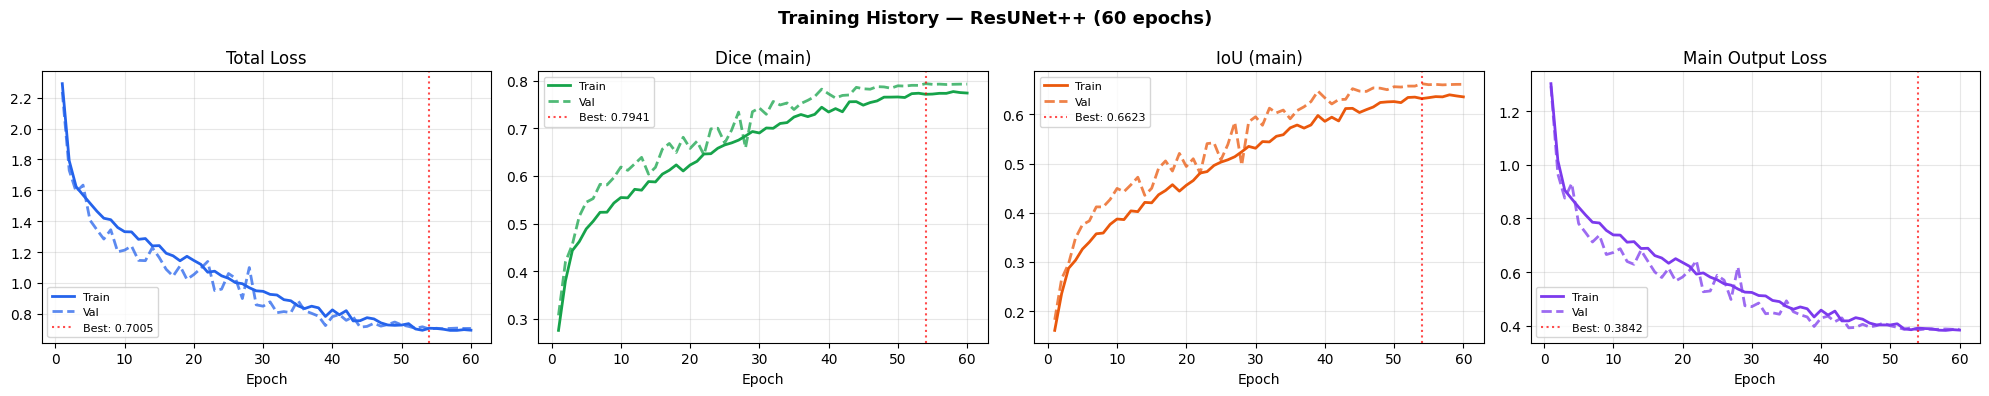

Best results:
  val_output_dice_coef: 0.7941 at epoch 54
  val_output_iou_metric: 0.6623 at epoch 54
  val_loss: 0.7005 at epoch 54


In [21]:
import pandas as pd

if os.path.exists(CSV_LOG_PATH):
    log_df = pd.read_csv(CSV_LOG_PATH)
    print(f'Loaded CSV: {len(log_df)} epochs')
elif 'history' in vars() or 'history' in globals():
    log_df = pd.DataFrame(history.history)
    log_df.index.name = 'epoch'; log_df.reset_index(inplace=True)
    log_df.to_csv(CSV_LOG_PATH, index=False)
else:
    raise RuntimeError('Run Cell 11 first.')

def fc(df, *c): return next((x for x in c if x in df.columns), None)

epoch_col = fc(log_df, 'epoch', 'Epoch')
epochs    = (log_df[epoch_col]+1).tolist() if epoch_col else list(range(1, len(log_df)+1))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Training History — ResUNet++ (60 epochs)', fontsize=13, fontweight='bold')

def plot_one(ax, tc, vc, title, mode, color):
    if tc is None:
        ax.text(0.5,0.5,f'{title} n/a',ha='center',va='center',transform=ax.transAxes); return
    ax.plot(epochs, log_df[tc], label='Train', color=color, linewidth=2)
    if vc and vc in log_df.columns:
        ax.plot(epochs, log_df[vc], label='Val', color=color, linewidth=2, linestyle='--', alpha=0.75)
        bv  = log_df[vc].max() if mode=='max' else log_df[vc].min()
        bi  = log_df[vc].idxmax() if mode=='max' else log_df[vc].idxmin()
        bep = log_df[epoch_col].iloc[bi]+1 if epoch_col else bi+1
        ax.axvline(x=bep,color='red',linestyle=':',alpha=0.7,label=f'Best: {bv:.4f}')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

plot_one(axes[0], fc(log_df,'loss'),                   fc(log_df,'val_loss'),                   'Total Loss',   'min','#2563EB')
plot_one(axes[1], fc(log_df,'output_dice_coef','dice_coef'), fc(log_df,'val_output_dice_coef','val_dice_coef'), 'Dice (main)', 'max','#16A34A')
plot_one(axes[2], fc(log_df,'output_iou_metric','iou_metric'),fc(log_df,'val_output_iou_metric','val_iou_metric'),'IoU (main)',  'max','#EA580C')
plot_one(axes[3], fc(log_df,'output_loss'),             fc(log_df,'val_output_loss'),             'Main Output Loss','min','#7C3AED')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

print('Best results:')
for col in ['val_output_dice_coef','val_output_iou_metric','val_loss']:
    if col in log_df.columns:
        fn = 'max' if 'dice' in col or 'iou' in col else 'min'
        bv = log_df[col].max() if fn=='max' else log_df[col].min()
        bi = log_df[col].idxmax() if fn=='max' else log_df[col].idxmin()
        ep = log_df[epoch_col].iloc[bi]+1 if epoch_col else bi+1
        print(f'  {col}: {bv:.4f} at epoch {ep}')


## Cell 13 - Evaluate on Test Set with 8-Fold TTA

**Test-Time Augmentation (TTA):** Each test image is predicted 8 times (4 rotations x 2 flips), predictions are averaged before binarisation. Typically adds +0.5 to +1.5% Dice over single-pass inference.


In [24]:
import os
import zipfile
import math
import numpy as np
import tensorflow as tf
import cv2
from glob import glob
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, BatchNormalization, Activation,
    GlobalAveragePooling2D, Reshape, Dense, Multiply, Add, Concatenate,
    MaxPool2D, Lambda
)
from tensorflow.keras.models import Model

# ── Config ────────────────────────────────────────────────────────────────────
OUTPUT_DIR = '/content/outputs'
MODEL_PATH = os.path.join(OUTPUT_DIR, 'best_model.keras')
PRED_DIR = os.path.join(OUTPUT_DIR, 'predictions')

IMG_SIZE = 352
BATCH_SIZE = 8
BASE_FILTERS = globals().get('BASE_FILTERS', 32)
SEED = 42
THRESHOLD = 0.5
NUM_SAMPLES = 10

os.makedirs(PRED_DIR, exist_ok=True)
tf.config.optimizer.set_jit(False)


# ── Metrics / losses ──────────────────────────────────────────────────────────
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * inter + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - inter
    return (inter + smooth) / (union + smooth)


def focal_tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1.0 - y_pred_f))
    fp = tf.reduce_sum((1.0 - y_true_f) * y_pred_f)

    tvi = (tp + smooth) / (tp + alpha * fn + beta * fp + smooth)
    return tf.pow(1.0 - tvi, gamma)


def boundary_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    kernel = tf.ones([5, 5, 1, 1], dtype=tf.float32)

    dilated = tf.cast(
        tf.nn.conv2d(y_true, kernel, strides=[1, 1, 1, 1], padding='SAME') > 0.5,
        tf.float32
    )
    eroded = 1.0 - tf.cast(
        tf.nn.conv2d(1.0 - y_true, kernel, strides=[1, 1, 1, 1], padding='SAME') > 0.5,
        tf.float32
    )

    boundary = dilated - eroded
    bce = tf.keras.losses.binary_crossentropy(y_true * boundary, y_pred * boundary)
    return tf.reduce_mean(bce)


def combined_loss(y_true, y_pred):
    return 0.8 * focal_tversky_loss(y_true, y_pred) + 0.2 * boundary_loss(y_true, y_pred)


# ── Model definition ──────────────────────────────────────────────────────────
def squeeze_excite(x, ratio=8):
    filters = int(x.shape[-1])
    se = GlobalAveragePooling2D()(x)
    se = Reshape((1, 1, filters))(se)
    se = Dense(max(filters // ratio, 1), activation='relu', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', use_bias=False)(se)
    return Multiply()([x, se])


def residual_block(x, filters, strides=1):
    shortcut = x

    if int(x.shape[-1]) != filters or strides != 1:
        shortcut = Conv2D(
            filters, 1, strides=strides, padding='same',
            use_bias=False, kernel_initializer='he_normal'
        )(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(
        filters, 3, strides=strides, padding='same',
        use_bias=False, kernel_initializer='he_normal'
    )(x)

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(
        filters, 3, padding='same',
        use_bias=False, kernel_initializer='he_normal'
    )(x)

    x = squeeze_excite(x)
    x = Add()([x, shortcut])
    return x


def resize_like(source, target, channels):
    target_size = Lambda(lambda t: tf.shape(t)[1:3])(target)

    target_h = int(target.shape[1]) if target.shape[1] is not None else None
    target_w = int(target.shape[2]) if target.shape[2] is not None else None

    return Lambda(
        lambda args: tf.image.resize(args[0], args[1], method='bilinear'),
        output_shape=(target_h, target_w, channels)
    )([source, target_size])


def aspp_block(x, filters):
    b0 = Conv2D(filters, 1, padding='same', use_bias=False)(x)
    b0 = BatchNormalization()(b0)
    b0 = Activation('relu')(b0)

    def dilated(inp, rate):
        y = Conv2D(
            filters, 3, padding='same', dilation_rate=rate,
            use_bias=False, kernel_initializer='he_normal'
        )(inp)
        y = BatchNormalization()(y)
        y = Activation('relu')(y)
        return y

    b1 = dilated(x, 1)
    b2 = dilated(x, 3)
    b3 = dilated(x, 6)
    b4 = dilated(x, 12)

    bg = GlobalAveragePooling2D()(x)
    bg = Reshape((1, 1, int(x.shape[-1])))(bg)
    bg = Conv2D(filters, 1, padding='same', use_bias=False)(bg)
    bg = BatchNormalization()(bg)
    bg = Activation('relu')(bg)
    bg = resize_like(bg, x, filters)

    concat = Concatenate(axis=-1)([b0, b1, b2, b3, b4, bg])

    out = Conv2D(filters, 1, padding='same', use_bias=False)(concat)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    return out


def attention_gate(g, x, filters):
    theta_x = Conv2D(filters, 1, padding='same', use_bias=False)(x)
    phi_g = Conv2D(filters, 1, padding='same', use_bias=False)(g)

    phi_g = resize_like(phi_g, theta_x, filters)

    add = Add()([theta_x, phi_g])
    add = Activation('relu')(add)

    psi = Conv2D(1, 1, padding='same', use_bias=False)(add)
    psi = Activation('sigmoid')(psi)

    return Multiply()([x, psi])


def decoder_block(x, skip, filters):
    x = Conv2DTranspose(
        filters, 2, strides=2, padding='same',
        kernel_initializer='he_normal'
    )(x)

    skip = attention_gate(g=x, x=skip, filters=max(filters // 2, 1))

    x = Concatenate(axis=-1)([x, skip])
    x = residual_block(x, filters)
    return x


def build_resunet_plus_plus(input_shape=(352, 352, 3), base_filters=32):
    f = [base_filters * (2 ** i) for i in range(5)]

    inputs = Input(input_shape, name='input')

    x = Conv2D(
        f[0], 3, padding='same', use_bias=False,
        kernel_initializer='he_normal'
    )(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    e1 = residual_block(x, f[0])
    p1 = MaxPool2D(pool_size=(2, 2))(e1)

    e2 = residual_block(p1, f[1])
    p2 = MaxPool2D(pool_size=(2, 2))(e2)

    e3 = residual_block(p2, f[2])
    p3 = MaxPool2D(pool_size=(2, 2))(e3)

    e4 = residual_block(p3, f[3])
    p4 = MaxPool2D(pool_size=(2, 2))(e4)

    bridge = aspp_block(p4, f[4])

    d4 = decoder_block(bridge, e4, f[3])
    d3 = decoder_block(d4, e3, f[2])
    d2 = decoder_block(d3, e2, f[1])
    d1 = decoder_block(d2, e1, f[0])

    out_main = Conv2D(
        1, 1, activation='sigmoid', name='output',
        dtype='float32'
    )(d1)

    out_d3 = Conv2D(1, 1, activation='sigmoid', dtype='float32')(d3)
    out_d3 = tf.keras.layers.Resizing(
        input_shape[0], input_shape[1],
        interpolation='bilinear',
        name='ds3'
    )(out_d3)

    out_d2 = Conv2D(1, 1, activation='sigmoid', dtype='float32')(d2)
    out_d2 = tf.keras.layers.Resizing(
        input_shape[0], input_shape[1],
        interpolation='bilinear',
        name='ds2'
    )(out_d2)

    return Model(inputs, [out_main, out_d3, out_d2], name='ResUNet_plusplus')


# ── Rebuild model and load weights from .keras archive ────────────────────────
assert os.path.exists(MODEL_PATH), f'Model not found at {MODEL_PATH}. Train/save the model first.'

print(f'Loading weights from: {MODEL_PATH}')

best_model = build_resunet_plus_plus(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    base_filters=BASE_FILTERS
)

EXTRACT_DIR = os.path.join(OUTPUT_DIR, 'best_model_extracted')
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(MODEL_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

WEIGHTS_PATH = os.path.join(EXTRACT_DIR, 'model.weights.h5')
assert os.path.exists(WEIGHTS_PATH), f'Weights file not found inside {MODEL_PATH}'

best_model.load_weights(WEIGHTS_PATH)
best_model.jit_compile = False

print('Model output names:', best_model.output_names)

main_name = best_model.output_names[0]
ds3_name = best_model.output_names[1]
ds2_name = best_model.output_names[2]

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss={
        main_name: combined_loss,
        ds3_name: combined_loss,
        ds2_name: combined_loss,
    },
    loss_weights={
        main_name: 1.0,
        ds3_name: 0.3,
        ds2_name: 0.3,
    },
    metrics={
        main_name: [dice_coef, iou_metric],
        ds3_name: [],
        ds2_name: [],
    },
    jit_compile=False
)

print('Model rebuilt, weights loaded, and recompiled.')


# ── Build test dataset ────────────────────────────────────────────────────────
DATASET_ROOT = '/content/kvasir-seg'
IMAGE_DIR, MASK_DIR = None, None

for root, dirs, _ in os.walk(DATASET_ROOT):
    if 'images' in dirs:
        IMAGE_DIR = os.path.join(root, 'images')
    if 'masks' in dirs:
        MASK_DIR = os.path.join(root, 'masks')

assert IMAGE_DIR and MASK_DIR, 'Dataset not found. Run the dataset setup cell first.'

images = sorted(glob(os.path.join(IMAGE_DIR, '*')))
masks = sorted(glob(os.path.join(MASK_DIR, '*')))

assert len(images) == len(masks) and len(images) > 0, 'Images/masks not found or count mismatch.'

_, test_x, _, test_y = train_test_split(
    images,
    masks,
    test_size=0.10,
    random_state=SEED
)


def read_image(path):
    path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype(np.float32) / 255.0


def read_mask(path):
    path = path.decode()
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    mask = mask.astype(np.float32) / 255.0
    return np.expand_dims(mask, axis=-1)


def parse_test(x_path, y_path):
    x, y = tf.numpy_function(
        lambda a, b: (read_image(a), read_mask(b)),
        [x_path, y_path],
        [tf.float32, tf.float32]
    )
    x.set_shape([IMG_SIZE, IMG_SIZE, 3])
    y.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return x, y


test_ds = (
    tf.data.Dataset.from_tensor_slices((test_x, test_y))
    .map(parse_test, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds_multi = test_ds.map(
    lambda x, y: (
        x,
        {
            main_name: y,
            ds3_name: y,
            ds2_name: y,
        }
    ),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

print(f'Rebuilt test_ds ({len(test_x)} samples)')


# ── Standard evaluation ───────────────────────────────────────────────────────
print('\nStandard evaluation single pass...')
results = best_model.evaluate(test_ds_multi, verbose=1)

if not isinstance(results, list):
    results = [results]

result_dict = dict(zip(best_model.metrics_names, results))

print('\n' + '=' * 50)
print('  TEST SET - SINGLE PASS')
print('=' * 50)
for k, v in result_dict.items():
    print(f'  {k:<35} : {float(v):.4f}')
print('=' * 50)


# ── TTA helpers ───────────────────────────────────────────────────────────────
def get_main_prediction(model, img):
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
    if isinstance(pred, (list, tuple)):
        pred = pred[0]
    return np.squeeze(pred).astype(np.float32)


def tta_predict(model, img_norm):
    preds = []

    for flip_h in [False, True]:
        for flip_v in [False, True]:
            aug = img_norm.copy()

            if flip_h:
                aug = aug[:, ::-1, :]
            if flip_v:
                aug = aug[::-1, :, :]

            pred = get_main_prediction(model, aug)

            if flip_v:
                pred = pred[::-1, :]
            if flip_h:
                pred = pred[:, ::-1]

            preds.append(pred)

            aug90 = np.rot90(aug, k=1)
            pred90 = get_main_prediction(model, aug90)
            pred90 = np.rot90(pred90, k=-1)

            if flip_v:
                pred90 = pred90[::-1, :]
            if flip_h:
                pred90 = pred90[:, ::-1]

            preds.append(pred90)

    return np.mean(preds, axis=0)


def metrics_np(gt, pred):
    gt = (gt > 0.5).astype(np.float32)
    pred = (pred > 0.5).astype(np.float32)

    inter = np.sum(gt * pred)
    pred_sum = np.sum(pred)
    gt_sum = np.sum(gt)

    dice = (2.0 * inter + 1e-6) / (gt_sum + pred_sum + 1e-6)
    iou = (inter + 1e-6) / (gt_sum + pred_sum - inter + 1e-6)

    return dice, iou


# ── 8-fold TTA evaluation ─────────────────────────────────────────────────────
print('\n8-fold TTA evaluation...')

dice_scores_tta, iou_scores_tta = [], []
dice_scores_sp, iou_scores_sp = [], []

for i, (x_path, y_path) in tqdm(enumerate(zip(test_x, test_y)), total=len(test_x)):
    x = cv2.imread(x_path, cv2.IMREAD_COLOR)
    x = cv2.cvtColor(cv2.resize(x, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB)
    x_norm = x.astype(np.float32) / 255.0

    y = cv2.imread(y_path, cv2.IMREAD_GRAYSCALE)
    y = cv2.resize(y, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    y_norm = y.astype(np.float32) / 255.0

    sp_prob = get_main_prediction(best_model, x_norm)
    sp_mask = (sp_prob > THRESHOLD).astype(np.float32)

    tta_prob = tta_predict(best_model, x_norm)
    tta_mask = (tta_prob > THRESHOLD).astype(np.float32)

    d_sp, i_sp = metrics_np(y_norm, sp_mask)
    d_tta, i_tta = metrics_np(y_norm, tta_mask)

    dice_scores_sp.append(d_sp)
    iou_scores_sp.append(i_sp)
    dice_scores_tta.append(d_tta)
    iou_scores_tta.append(i_tta)

    if i < NUM_SAMPLES:
        x_bgr = cv2.cvtColor(x, cv2.COLOR_RGB2BGR)

        gt_vis = cv2.cvtColor((y_norm * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        sp_vis = cv2.cvtColor((sp_mask * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        tt_vis = cv2.cvtColor((tta_mask * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)

        ov = x_bgr.copy()
        gm = np.zeros_like(x_bgr)
        rm = np.zeros_like(x_bgr)

        gm[y_norm > 0.5] = [0, 200, 0]
        rm[tta_mask > 0.5] = [0, 50, 220]

        ov = cv2.addWeighted(ov, 0.6, gm, 0.25, 0)
        ov = cv2.addWeighted(ov, 1.0, rm, 0.25, 0)

        sep = np.ones((IMG_SIZE, 6, 3), np.uint8) * 255
        strip = np.concatenate(
            [x_bgr, sep, gt_vis, sep, sp_vis, sep, tt_vis, sep, ov],
            axis=1
        )

        fname = os.path.join(PRED_DIR, f'pred_{i:04d}_dice{d_tta:.3f}.png')
        cv2.imwrite(fname, strip)


print('\n' + '=' * 50)
print('  TEST SET FINAL RESULTS')
print('=' * 50)
print(f'  Single-pass  Dice : {np.mean(dice_scores_sp):.4f} +/- {np.std(dice_scores_sp):.4f}')
print(f'  Single-pass  IoU  : {np.mean(iou_scores_sp):.4f} +/- {np.std(iou_scores_sp):.4f}')
print(f'  TTA 8-fold   Dice : {np.mean(dice_scores_tta):.4f} +/- {np.std(dice_scores_tta):.4f}')
print(f'  TTA 8-fold   IoU  : {np.mean(iou_scores_tta):.4f} +/- {np.std(iou_scores_tta):.4f}')
print('=' * 50)
print(f'\nTTA improvement: +{(np.mean(dice_scores_tta) - np.mean(dice_scores_sp)) * 100:.2f}% Dice')
print(f'Predictions saved to: {PRED_DIR}')


Loading weights from: /content/outputs/best_model.keras
Model output names: ListWrapper(['output', 'ds3', 'ds2'])
Model rebuilt, weights loaded, and recompiled.
Rebuilt test_ds (100 samples)

Standard evaluation single pass...
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - ds2_loss: 0.2680 - ds3_loss: 0.2727 - loss: 0.4292 - output_dice_coef: 0.7796 - output_iou_metric: 0.6418 - output_loss: 0.2657

  TEST SET - SINGLE PASS
  loss                                : 0.4292
  compile_metrics                     : 0.2657
  output_loss                         : 0.2727
  ds3_loss                            : 0.2680
  ds2_loss                            : 0.7796

8-fold TTA evaluation...


  0%|          | 0/100 [00:00<?, ?it/s]


  TEST SET FINAL RESULTS
  Single-pass  Dice : 0.7776 +/- 0.2275
  Single-pass  IoU  : 0.6827 +/- 0.2546
  TTA 8-fold   Dice : 0.7791 +/- 0.2422
  TTA 8-fold   IoU  : 0.6899 +/- 0.2656

TTA improvement: +0.15% Dice
Predictions saved to: /content/outputs/predictions


## Cell 14 - Export for HuggingFace Deployment

Downloads `hf_deployment.zip`. Upload its contents + `app.py` to your HF Space.

```
your-hf-space/
    app.py
    best_model.h5
    requirements.txt
    README.md
```


In [26]:
import os
import shutil
import numpy as np
import tensorflow as tf

HF_DIR = '/content/hf_deployment'
os.makedirs(HF_DIR, exist_ok=True)

tf.config.optimizer.set_jit(False)

assert 'best_model' in globals(), 'best_model not found. Run the model loading/evaluation cell first.'

# Save H5
h5_path = os.path.join(HF_DIR, 'best_model.h5')
best_model.save(h5_path, include_optimizer=False)
print(f'Saved H5 -> {h5_path}  ({os.path.getsize(h5_path) / 1024 / 1024:.1f} MB)')


# Sanity check
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    i = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * i + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    i = tf.reduce_sum(y_true_f * y_pred_f)
    u = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - i
    return (i + smooth) / (u + smooth)


def focal_tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1.0 - y_pred_f))
    fp = tf.reduce_sum((1.0 - y_true_f) * y_pred_f)

    return tf.pow(1.0 - (tp + smooth) / (tp + alpha * fn + beta * fp + smooth), gamma)


def boundary_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    k = tf.ones([5, 5, 1, 1], dtype=tf.float32)

    d = tf.cast(
        tf.nn.conv2d(y_true, k, strides=[1, 1, 1, 1], padding='SAME') > 0.5,
        tf.float32
    )
    e = 1.0 - tf.cast(
        tf.nn.conv2d(1.0 - y_true, k, strides=[1, 1, 1, 1], padding='SAME') > 0.5,
        tf.float32
    )

    bnd = d - e
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true * bnd, y_pred * bnd))


def combined_loss(y_true, y_pred):
    return 0.8 * focal_tversky_loss(y_true, y_pred) + 0.2 * boundary_loss(y_true, y_pred)


CUSTOM_OBJECTS = {
    'combined_loss': combined_loss,
    'focal_tversky_loss': focal_tversky_loss,
    'boundary_loss': boundary_loss,
    'dice_coef': dice_coef,
    'iou_metric': iou_metric,
}

try:
    rl = tf.keras.models.load_model(
        h5_path,
        custom_objects=CUSTOM_OBJECTS,
        compile=False
    )
    print('Reloaded H5 successfully.')
except Exception as e:
    print(f'H5 reload warning: {type(e).__name__}: {e}')
    print('Using in-memory best_model for sanity check.')
    rl = best_model

dummy = np.random.rand(1, 352, 352, 3).astype('float32')
out = rl.predict(dummy, verbose=0)

if isinstance(out, (list, tuple)):
    out = out[0]

assert out.shape == (1, 352, 352, 1), f'Bad shape: {out.shape}'
assert 0.0 <= float(out.min()) <= float(out.max()) <= 1.0, 'Out of range'

print(f'H5 verified - shape:{out.shape}  range:[{out.min():.3f},{out.max():.3f}]')


# requirements.txt
req = (
    'gradio>=4.0.0\n'
    'tensorflow>=2.12.0\n'
    'opencv-python-headless>=4.8.0\n'
    'numpy>=1.24.0\n'
    'Pillow>=10.0.0\n'
)

with open(os.path.join(HF_DIR, 'requirements.txt'), 'w') as f:
    f.write(req)

print('requirements.txt written')


# README
readme = (
    '---\n'
    'title: Polyp Segmentation\n'
    'sdk: gradio\n'
    'sdk_version: "4.0.0"\n'
    'app_file: app.py\n'
    'pinned: false\n'
    '---\n\n'
    '# Polyp Segmentation - ResUNet++ (High Accuracy)\n\n'
    'Architecture: ResUNet++ with ASPP + Attention Gates\n'
    'Dataset: Kvasir-SEG | Loss: Focal-Tversky + Boundary\n'
    'Input: 352x352x3 | Output: 352x352x1 (sigmoid)\n'
)

with open(os.path.join(HF_DIR, 'README.md'), 'w') as f:
    f.write(readme)

print('README.md written')


zip_base = '/content/hf_deployment'
zip_file = zip_base + '.zip'

if os.path.exists(zip_file):
    os.remove(zip_file)

shutil.make_archive(zip_base, 'zip', HF_DIR)

print(f'\nDeployment zip: {zip_file}  ({os.path.getsize(zip_file) / 1024 / 1024:.1f} MB)')

for fname in sorted(os.listdir(HF_DIR)):
    fpath = os.path.join(HF_DIR, fname)
    print(f'  {fname}  ({os.path.getsize(fpath) / 1024:.1f} KB)')


try:
    from google.colab import files
    files.download(zip_file)
    print('Download started!')
except Exception as e:
    print(f'Could not start automatic download: {e}')
    print(f'Manual download path: {zip_file}')


Saved H5 -> /content/hf_deployment/best_model.h5  (43.1 MB)
H5 reload warning: ValueError: Requested the deserialization of a `Lambda` layer whose `function` is a Python lambda. This carries a potential risk of arbitrary code execution and thus it is disallowed by default. If you trust the source of the artifact, you can override this error by passing `safe_mode=False` to the loading function, or calling `keras.config.enable_unsafe_deserialization().
Using in-memory best_model for sanity check.
H5 verified - shape:(1, 352, 352, 1)  range:[0.000,0.998]
requirements.txt written
README.md written

Deployment zip: /content/hf_deployment.zip  (39.5 MB)
  README.md  (0.3 KB)
  best_model.h5  (44106.6 KB)
  requirements.txt  (0.1 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


In [28]:
import numpy as np

dummy = np.random.rand(1, 352, 352, 3).astype("float32")
pred = model.predict(dummy, verbose=0)

if isinstance(pred, (list, tuple)):
    pred = pred[0]

print("Shape:", pred.shape)
print("Min:", pred.min(), "Max:", pred.max())



Shape: (1, 352, 352, 1)
Min: 2.2559014e-10 Max: 0.9900503
